In [0]:
# 1. Read the uploaded CSV file from your Volume
raw_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/Volumes/workspace/default/bronze_files/SCM.csv")

# 2. Save it as a Delta table named 'bronze_scm_raw'
raw_df.write.format("delta").mode("overwrite").saveAsTable("workspace.default.bronze_scm_raw")

print("Bronze table created successfully!")

Bronze table created successfully!


In [0]:
%sql
CREATE OR REPLACE TABLE workspace.default.silver_scm_cleansed AS
WITH medians AS (
    SELECT 
        WH_capacity_size, 
        PERCENTILE_APPROX(workers_num, 0.5) AS median_workers
    FROM workspace.default.bronze_scm_raw
    WHERE workers_num IS NOT NULL
    GROUP BY WH_capacity_size
)
SELECT 
    b.Ware_house_ID,
    b.WH_Manager_ID,
    b.Location_type,
    b.WH_capacity_size,
    b.zone,
    b.WH_regional_zone,
    b.wh_owner_type,
    COALESCE(b.workers_num, m.median_workers) AS workers_num,
    COALESCE(b.approved_wh_govt_certificate, 'Uncertified') AS approved_wh_govt_certificate,
    b.transport_issue_l1y,
    b.wh_breakdown_l3m,
    b.storage_issue_reported_l3m,
    b.temp_reg_mach,
    b.flood_impacted,
    b.flood_proof,
    b.electric_supply,
    b.dist_from_hub,
    b.product_wg_ton
FROM workspace.default.bronze_scm_raw b
LEFT JOIN medians m ON b.WH_capacity_size = m.WH_capacity_size;

num_affected_rows,num_inserted_rows


In [0]:
%sql
CREATE OR REPLACE TABLE workspace.default.gold_scm_kpis AS
SELECT 
    zone,
    WH_capacity_size,
    COUNT(Ware_house_ID) AS total_warehouses,
    ROUND(SUM(product_wg_ton) / 1000, 2) AS total_weight_thousands_ton,
    SUM(transport_issue_l1y) AS total_transport_issues,
    SUM(wh_breakdown_l3m) AS total_breakdowns,
    ROUND(AVG(dist_from_hub), 1) AS avg_dist_from_hub
FROM workspace.default.silver_scm_cleansed
GROUP BY zone, WH_capacity_size;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM workspace.default.gold_scm_kpis;


zone,WH_capacity_size,total_warehouses,total_weight_thousands_ton,total_transport_issues,total_breakdowns,avg_dist_from_hub
South,Large,1426,31342.84,1032,4927,164.8
East,Mid,225,5190.77,186,803,161.0
West,Large,2659,57755.62,1919,9294,163.9
South,Small,1370,29979.33,1151,4745,163.9
West,Mid,3167,71039.25,2467,11221,164.7
East,Large,62,1445.93,38,224,150.7
North,Mid,2662,59082.35,2088,9221,163.5
East,Small,95,2048.92,73,321,168.2
West,Small,1229,26662.24,971,4279,161.3
South,Mid,2848,62288.78,2230,9914,163.8


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
SELECT approved_wh_govt_certificate, product_wg_ton
FROM workspace.default.silver_scm_cleansed;



approved_wh_govt_certificate,product_wg_ton
A,17115
A,5074
A,23137
A+,22115
C,24071
A+,32134
B,30142
C,24093
A+,18082
C,7130


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
SELECT 
    Location_type,
    CASE WHEN temp_reg_mach = 1 THEN 'Has Temp Control' ELSE 'No Temp Control' END AS temp_machine_status,
    ROUND(AVG(storage_issue_reported_l3m), 2) AS avg_storage_issues
FROM workspace.default.silver_scm_cleansed
GROUP BY Location_type, temp_reg_mach;

Location_type,temp_machine_status,avg_storage_issues
Urban,No Temp Control,19.57
Rural,No Temp Control,16.49
Rural,Has Temp Control,17.86
Urban,Has Temp Control,19.43


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
SELECT wh_owner_type, COUNT(*) AS warehouse_count
FROM workspace.default.silver_scm_cleansed
GROUP BY wh_owner_type;

wh_owner_type,warehouse_count
Rented,10115
Company Owned,12035


Databricks visualization. Run in Databricks to view.

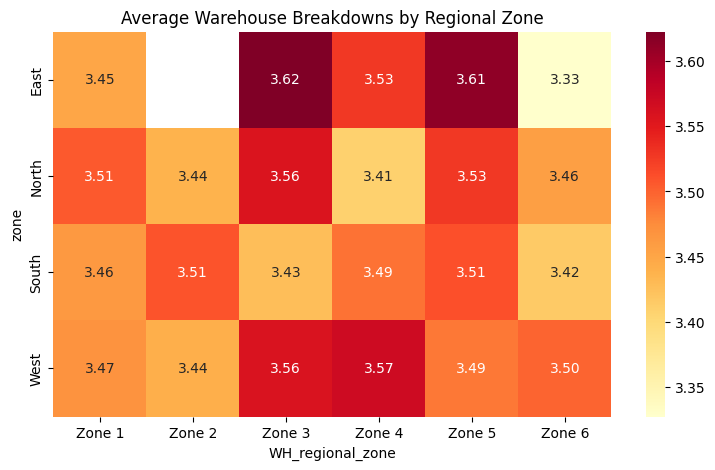

In [0]:
%python
import matplotlib.pyplot as plt
import seaborn as sns

# Query Silver table into a pandas dataframe
df = spark.sql("""
    SELECT zone, WH_regional_zone, AVG(wh_breakdown_l3m) as avg_breakdowns
    FROM workspace.default.silver_scm_cleansed
    GROUP BY zone, WH_regional_zone
""").toPandas()

# Pivot data for heatmap
pivot_table = df.pivot(index='zone', columns='WH_regional_zone', values='avg_breakdowns')

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_table, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Average Warehouse Breakdowns by Regional Zone")
plt.show()